In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/sharmajicoder/why-gen-z-are-not-posting-on-social-media/genz_social_media_behavior.csv


Dataset Link :- https://www.kaggle.com/datasets/sharmajicoder/why-gen-z-are-not-posting-on-social-media

In [2]:
data = pd.read_csv("/kaggle/input/datasets/sharmajicoder/why-gen-z-are-not-posting-on-social-media/genz_social_media_behavior.csv")

# 1. Understanding Data

In [3]:
df = pd.DataFrame(data)
df.head()

,age,daily_screen_time,num_platforms_used,social_anxiety_score,self_esteem_score,privacy_concern,trend_fatigue,burnout_level,comparison_tendency,attention_span,posting_probability,is_active_poster,posting_decline_reason
0,22,3.050197,2,2,2,2,10,7,9,35,0.20,0,Low Interest
1,19,2.857721,1,4,10,0,5,3,1,31,0.42,1,Low Interest
2,28,5.714027,3,6,5,2,0,2,9,21,0.24,0,Low Interest
3,26,4.089610,3,1,6,0,6,7,2,9,0.35,1,Low Interest
4,23,3.593140,3,1,7,5,1,10,9,43,0.21,0,Burnout


In [4]:
df.shape

(1000000, 13)

In [5]:
print("Total Duplicates : ",df.duplicated().sum())

Total Duplicates :  0


In [6]:
df.isna().sum()[df.isna().sum() > 0]

Series([], dtype: int64)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 13 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   age                     1000000 non-null  int64  
 1   daily_screen_time       1000000 non-null  float64
 2   num_platforms_used      1000000 non-null  int64  
 3   social_anxiety_score    1000000 non-null  int64  
 4   self_esteem_score       1000000 non-null  int64  
 5   privacy_concern         1000000 non-null  int64  
 6   trend_fatigue           1000000 non-null  int64  
 7   burnout_level           1000000 non-null  int64  
 8   comparison_tendency     1000000 non-null  int64  
 9   attention_span          1000000 non-null  int64  
 10  posting_probability     1000000 non-null  float64
 11  is_active_poster        1000000 non-null  int64  
 12  posting_decline_reason  1000000 non-null  object 
dtypes: float64(2), int64(10), object(1)
memory usage: 99.2+ MB

Above shows we only have one object variable

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1000000.0,22.494254,4.031665,16.0,19.000000,22.000000,26.000000,29.000000
daily_screen_time,1000000.0,4.001982,1.495497,0.0,2.988697,4.000457,5.008822,10.992968
num_platforms_used,1000000.0,3.000246,1.414307,1.0,2.000000,3.000000,4.000000,5.000000
social_anxiety_score,1000000.0,4.996911,3.163908,0.0,2.000000,5.000000,8.000000,10.000000
self_esteem_score,1000000.0,5.002528,3.161290,0.0,2.000000,5.000000,8.000000,10.000000
privacy_concern,1000000.0,4.999908,3.161279,0.0,2.000000,5.000000,8.000000,10.000000
trend_fatigue,1000000.0,5.001389,3.161241,0.0,2.000000,5.000000,8.000000,10.000000
burnout_level,1000000.0,5.003304,3.162251,0.0,2.000000,5.000000,8.000000,10.000000
comparison_tendency,1000000.0,5.003456,3.161952,0.0,2.000000,5.000000,8.000000,10.000000
attention_span,1000000.0,31.984325,15.856177,5.0,18.000000,32.000000,46.000000,59.000000


In [9]:
# Checking spelling
print("Total Number of Unique values : ",df['posting_decline_reason'].nunique())
print("Total Unique values : ",df['posting_decline_reason'].unique())

Total Number of Unique values :  4
Total Unique values :  ['Low Interest' 'Burnout' 'Fear of Judgment' 'Privacy Concern']


# 2. Data Cleaning

## Renaming Columns

In [10]:
df = df.rename(columns={
    "daily_screen_time": "screen_time_hours",
    "num_platforms_used": "platform_count",
    "social_anxiety_score": "social_anxiety",
    "self_esteem_score": "self_esteem",
    "privacy_concern": "privacy_score",
    "trend_fatigue": "trend_fatigue_score",
    "burnout_level": "burnout_score",
    "comparison_tendency": "social_comparison",
    "attention_span": "attention_span_score",
    "posting_probability": "post_probability",
    "is_active_poster": "active_poster",
    "posting_decline_reason": "decline_reason"
})

# 3. EDA

In [11]:
num_cols = df.select_dtypes(include=['int64','float64']).columns.drop('active_poster')
# Binary columns (better visualized with count plots)
extra_num_cols = ['active_poster']
cat_cols = df.select_dtypes(include='object').columns

## 3.1 Univariate Analysis

### 3.1.1 Numerical Columns

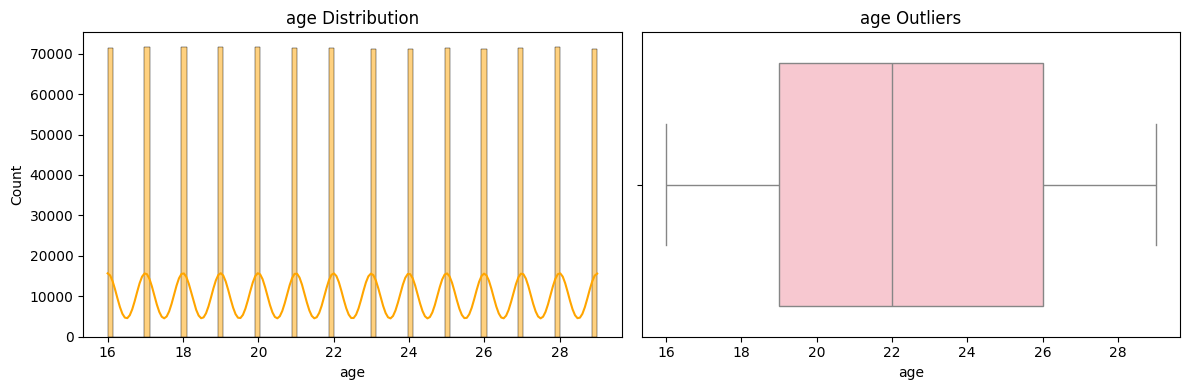

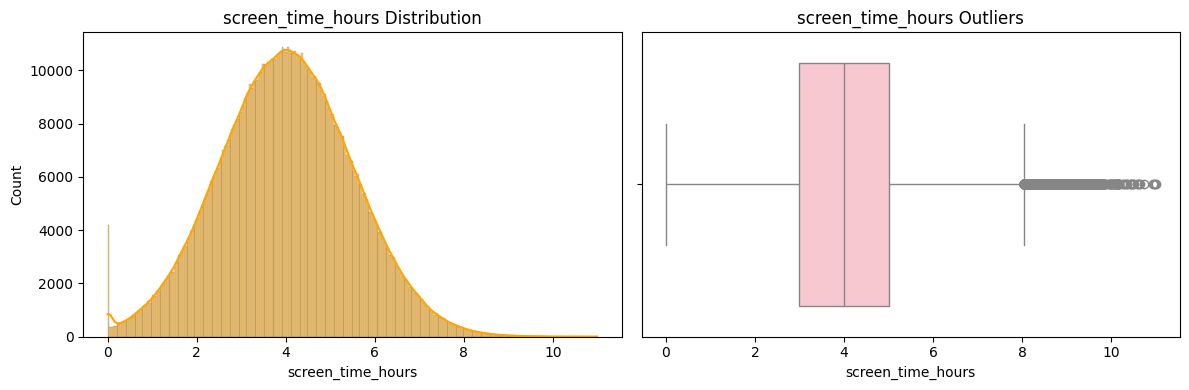

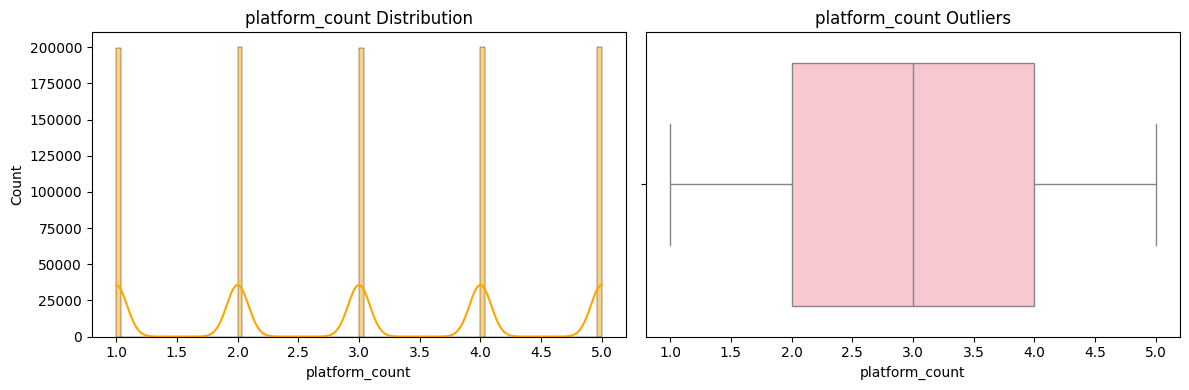

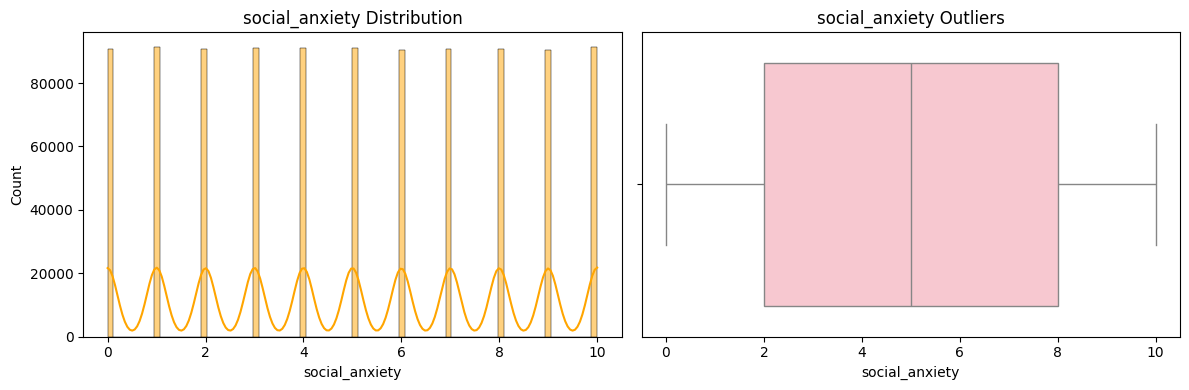

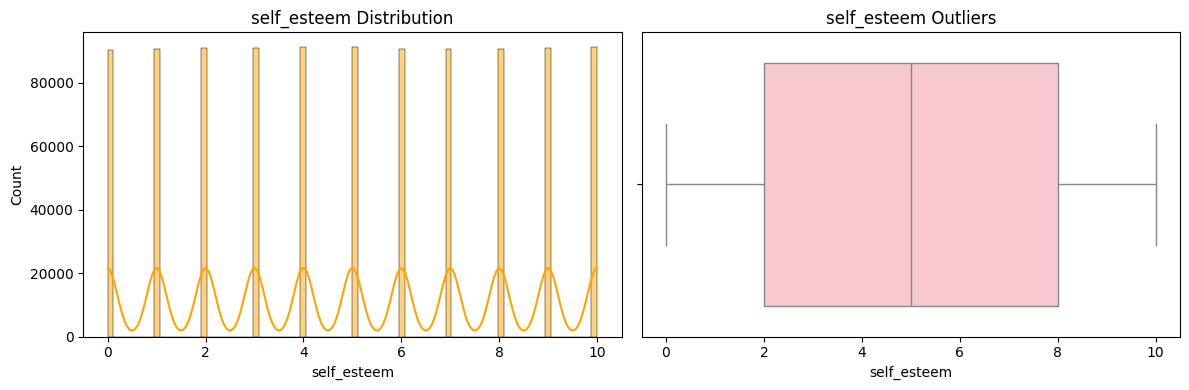

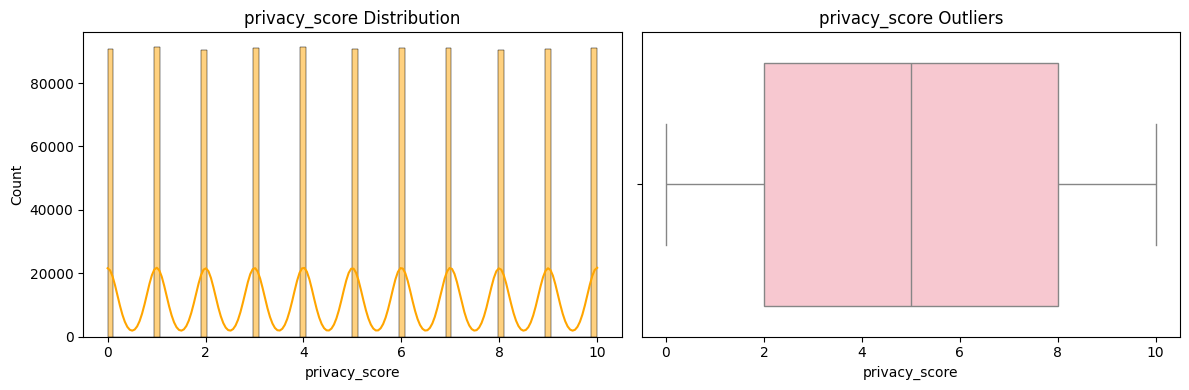

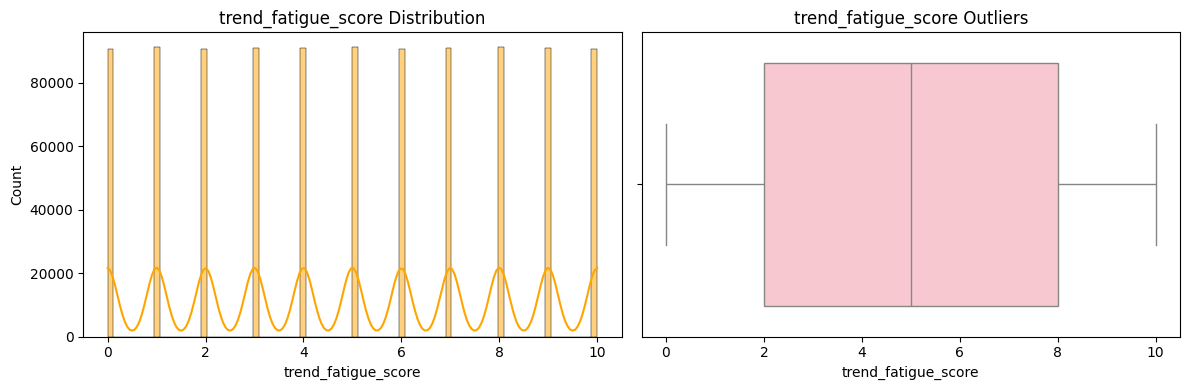

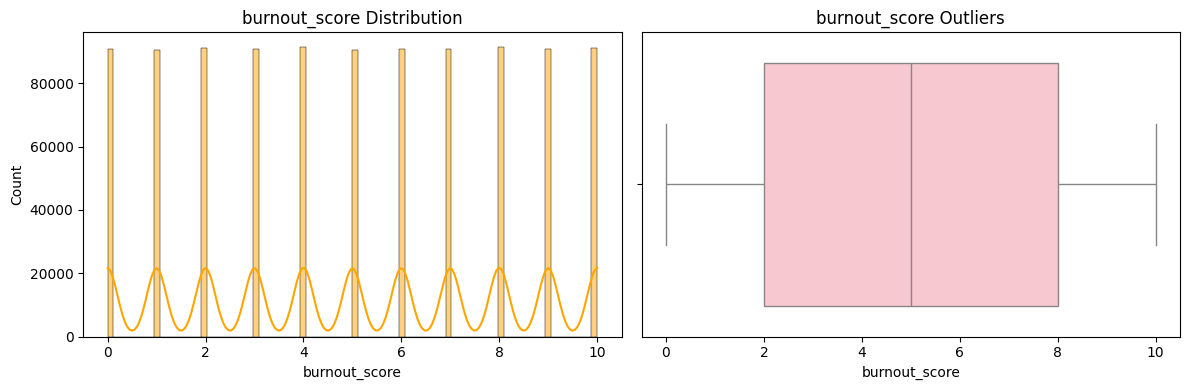

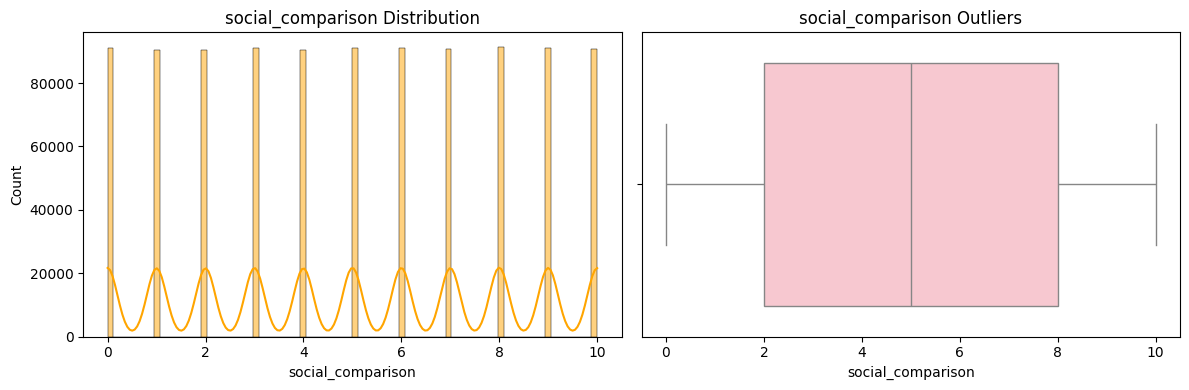

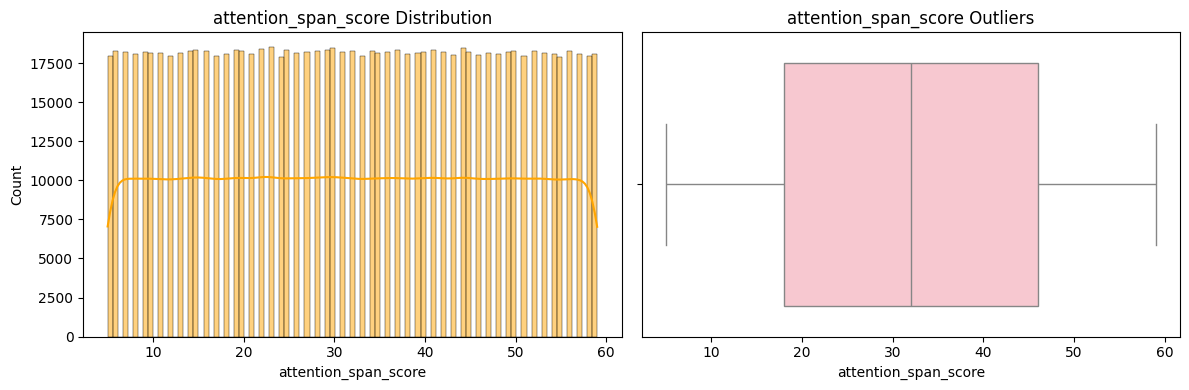

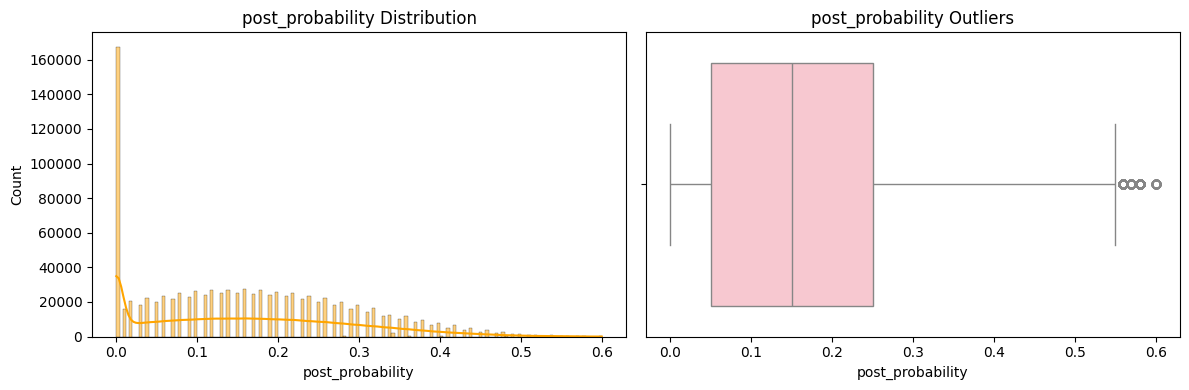

In [12]:
# Plot Histograms and Boxplots side-by-side for each numerical column
for col in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Histogram with KDE curve
    sns.histplot(data=df, x=col, kde=True, ax=axes[0], color='orange')
    axes[0].set_title(f'{col} Distribution')
    
    # Boxplot for outliers
    sns.boxplot(data=df, x=col, ax=axes[1], color='pink')
    axes[1].set_title(f'{col} Outliers')
    
    plt.tight_layout()
    plt.show()

`screen_time_hours` contains some outliers

### 3.1.2 Categorical  Columns

In [13]:
import math

def count_plot(cols):
    n = len(cols)
    rows = math.ceil(n / 2)

    plt.figure(figsize=(14, 5 * rows))

    for i, col in enumerate(cols, 1):
        plt.subplot(rows, 2, i)

        sns.countplot(
            data=df,
            x=col,
            order=df[col].value_counts().index,
            legend=True
        )

        plt.title(f'{col} Frequency')
        plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

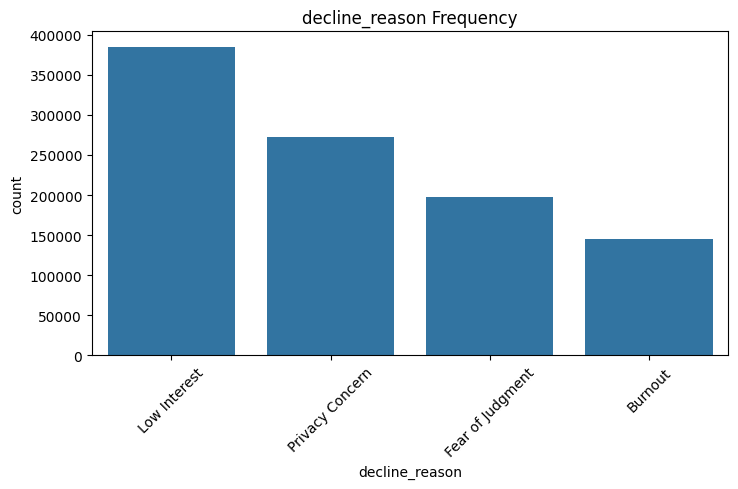

In [14]:
count_plot(cat_cols)

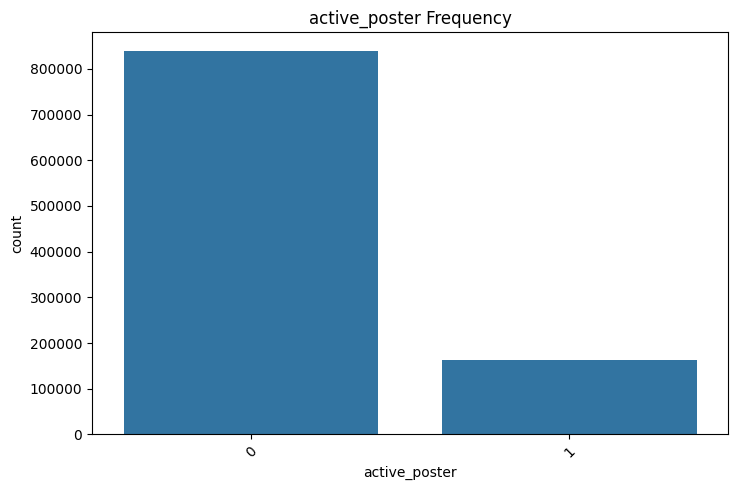

In [15]:
count_plot(extra_num_cols)

Data is biased towards not an `active_poster`

## 3.2 Bivariate Analysis

### 3.2.1 Numerical vs Numerical

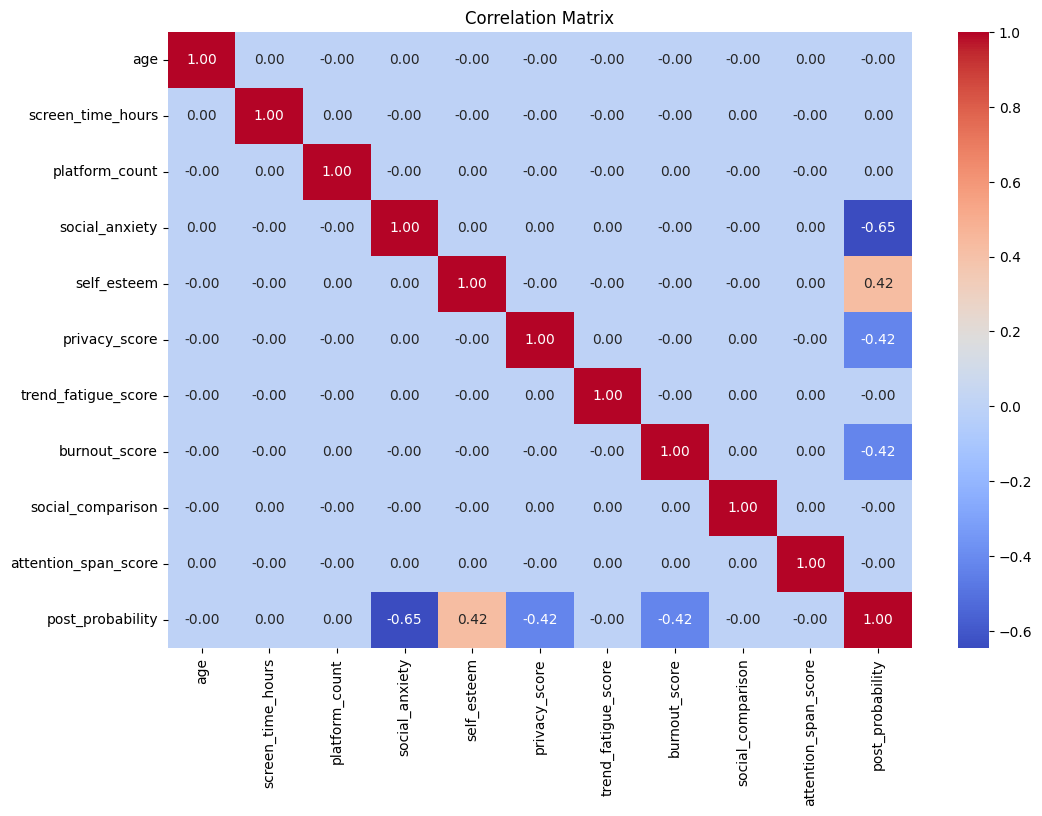

In [16]:
plt.figure(figsize=(12,8))
sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title("Correlation Matrix")
plt.show()

### 3.2.2 Numerical vs Categorical

In [17]:
df_sample = df.sample(25000)

**Box-Plot**

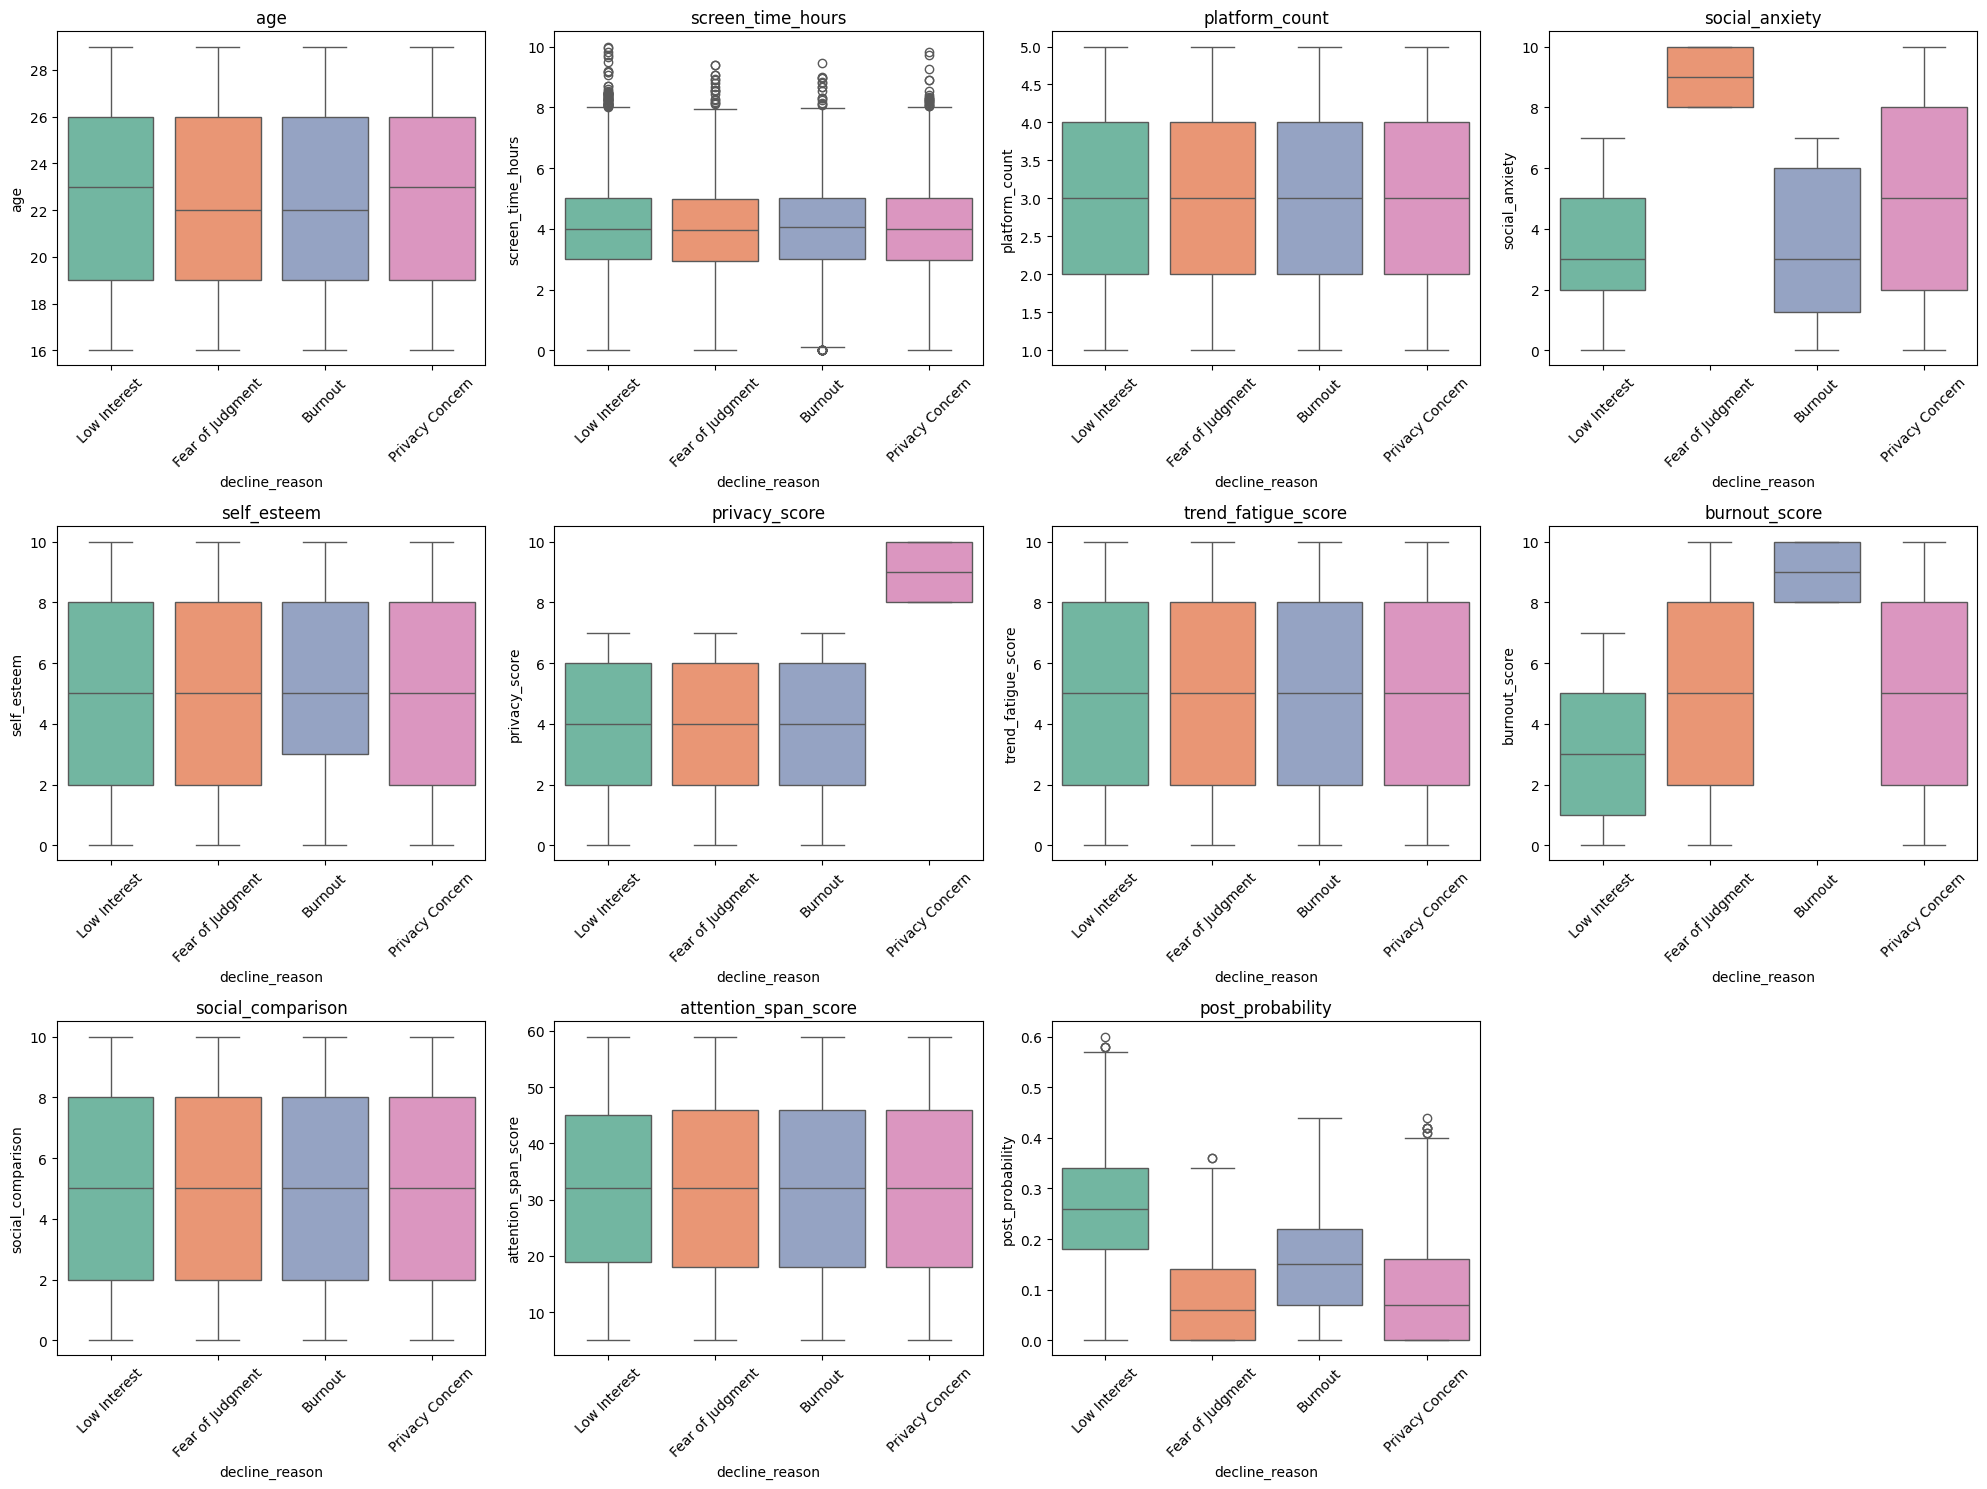

In [18]:
fig, axes = plt.subplots(3, 4, figsize=(20, 15))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(
    data=df_sample,
    x='decline_reason',
    y=col,
    hue='decline_reason',
    palette='Set2',
    legend=False,
    ax=axes[i]
    )
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)

# Remove the unused subplot
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Violin Plot**

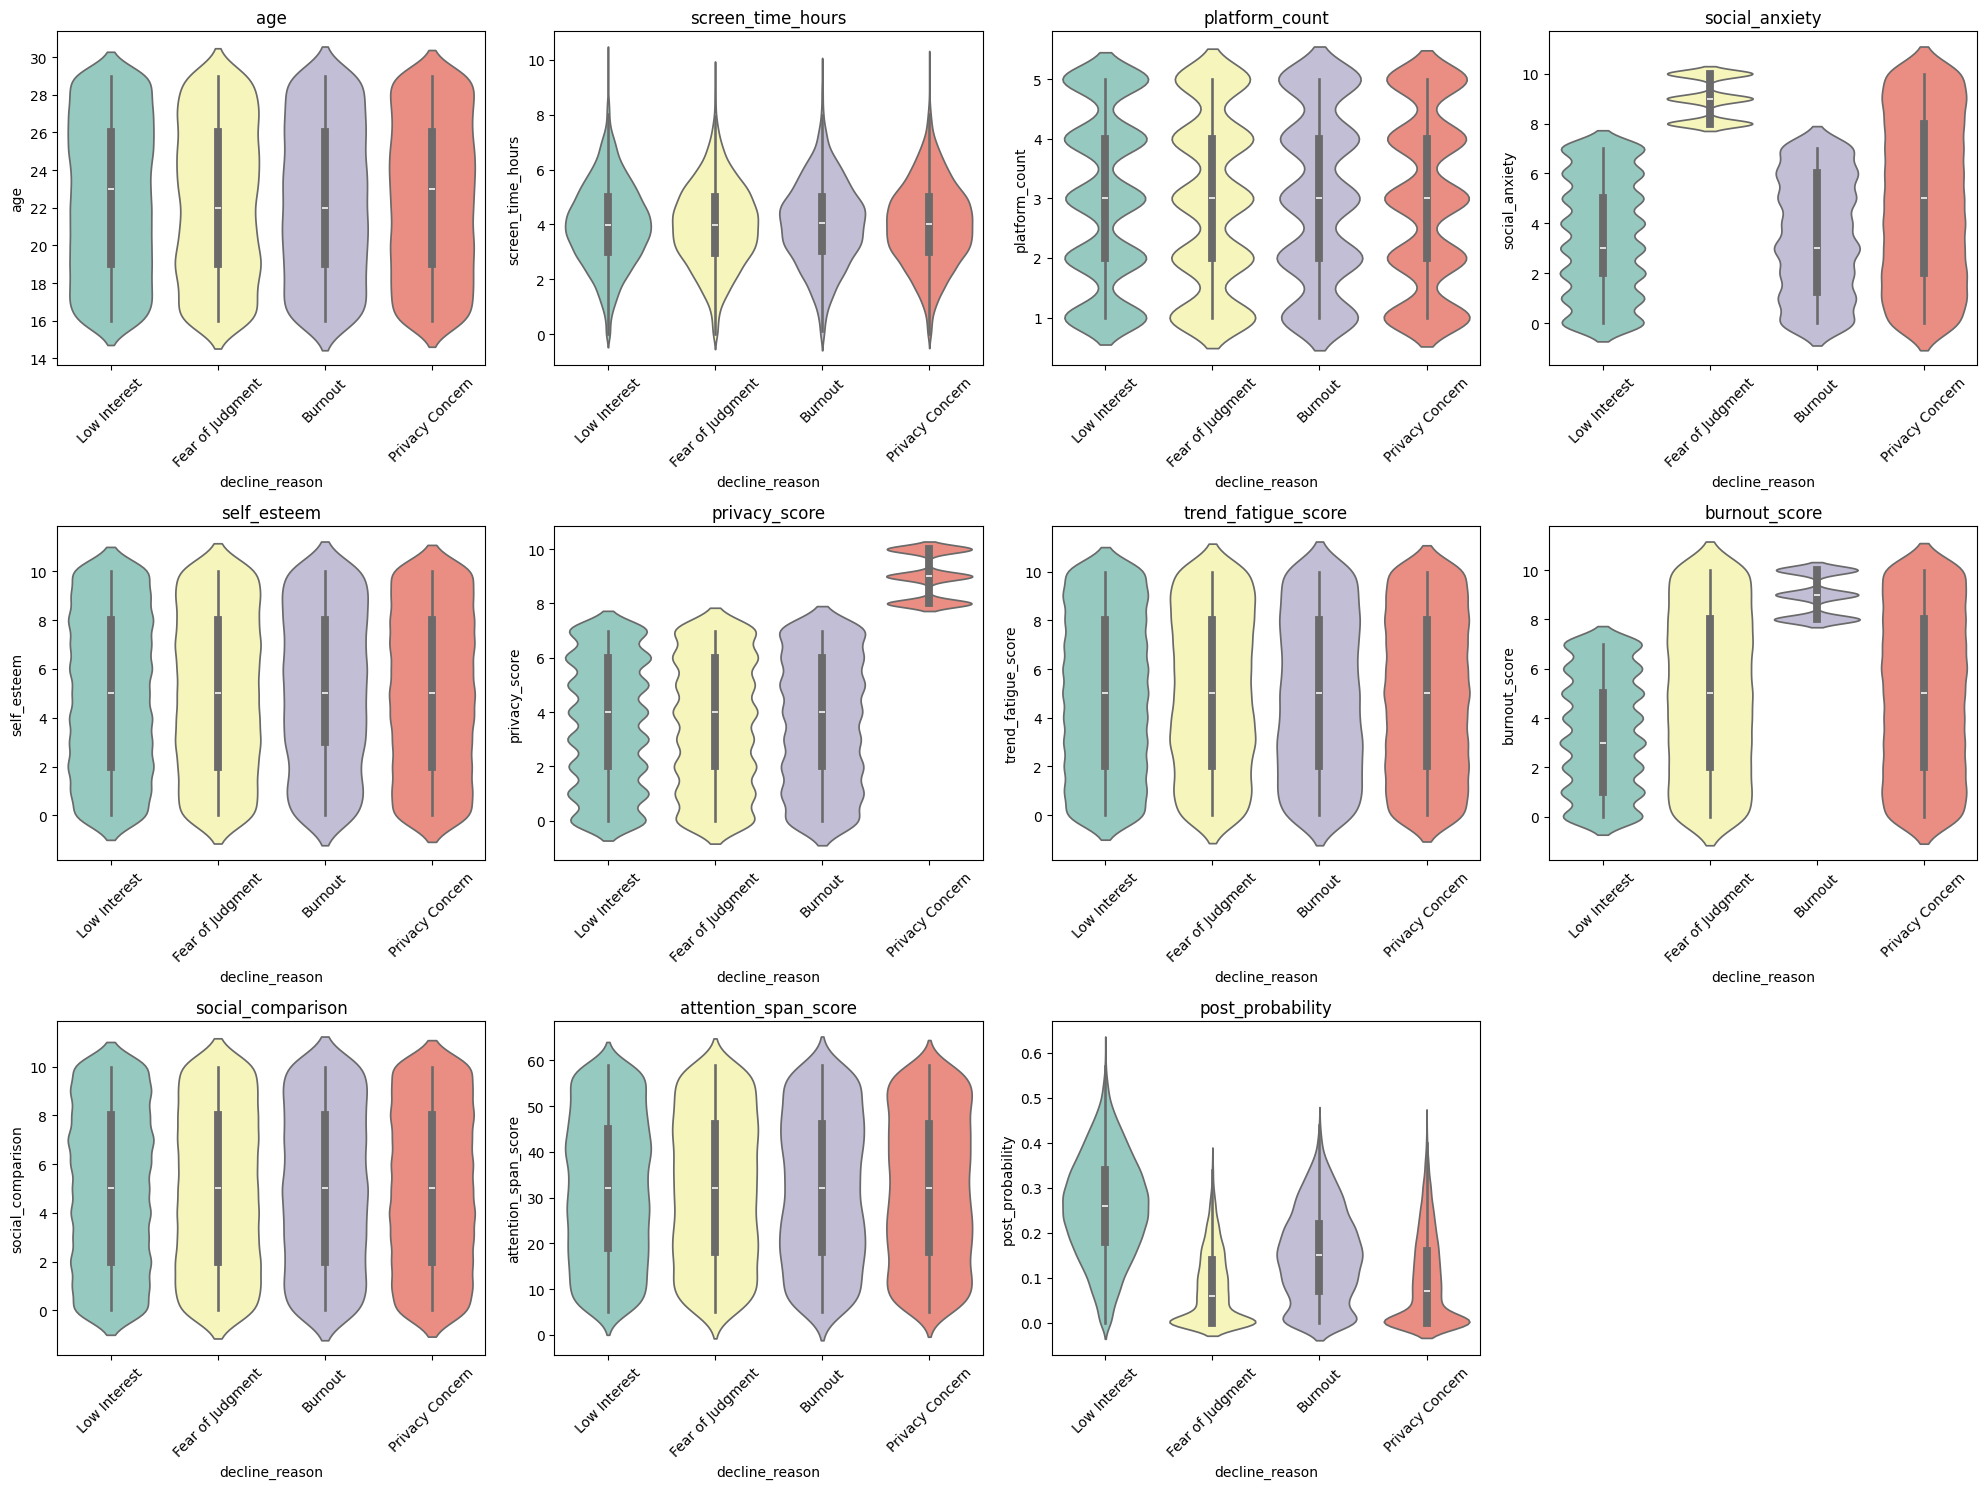

In [19]:
fig, axes = plt.subplots(3, 4, figsize=(20, 15))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.violinplot(
        data=df_sample,
        x='decline_reason',
        y=col,
        hue='decline_reason',
        palette='Set3',
        legend=False,
        ax=axes[i]
    )
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)

# Remove empty subplot
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## 3.3 Multivariate Analysis

**Pair Plot**

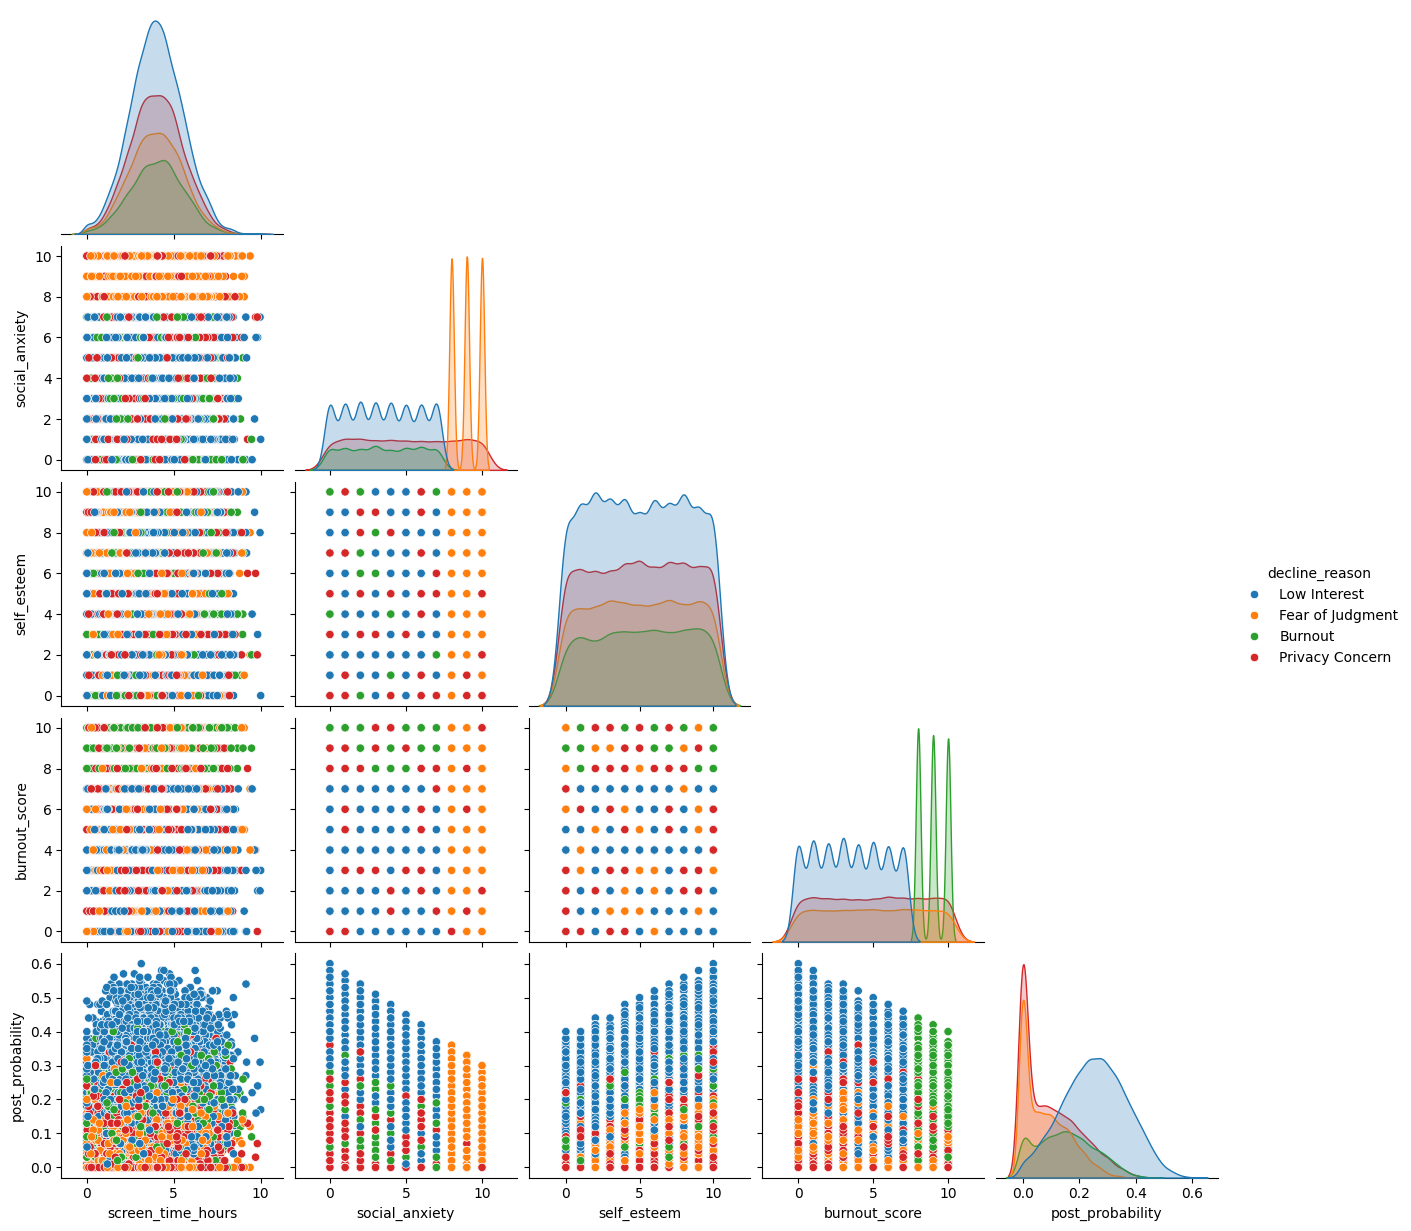

In [20]:
cols = [
    'screen_time_hours',
    'social_anxiety',
    'self_esteem',
    'burnout_score',
    'post_probability',
    'decline_reason'
]

sns.pairplot(
    df_sample[cols],
    hue='decline_reason',
    corner=True,
    diag_kind='kde'
)

plt.show()

**Scatterplot with Hue and Size**

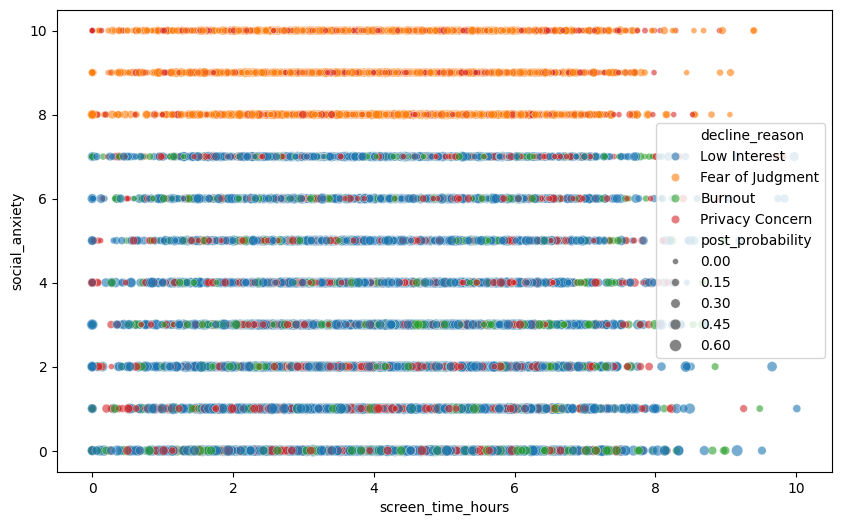

In [21]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_sample,
    x='screen_time_hours',
    y='social_anxiety',
    hue='decline_reason',
    size='post_probability',
    alpha=0.6
)

plt.show()

# 4. Feature transformation

In [22]:
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.model_selection import train_test_split

In [23]:
from scipy import stats
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
z_scores = np.abs(stats.zscore(df[num_cols], nan_policy='omit'))
outliers = (z_scores > 3).sum()
print(outliers)

2403


## 4.1 Power Transformation

In [24]:
from sklearn.preprocessing import PowerTransformer

skew_cols = [
    'screen_time_hours',
    'post_probability'
]

pt = PowerTransformer(method='yeo-johnson')

for col in skew_cols:
    df[col] = pt.fit_transform(df[[col]])

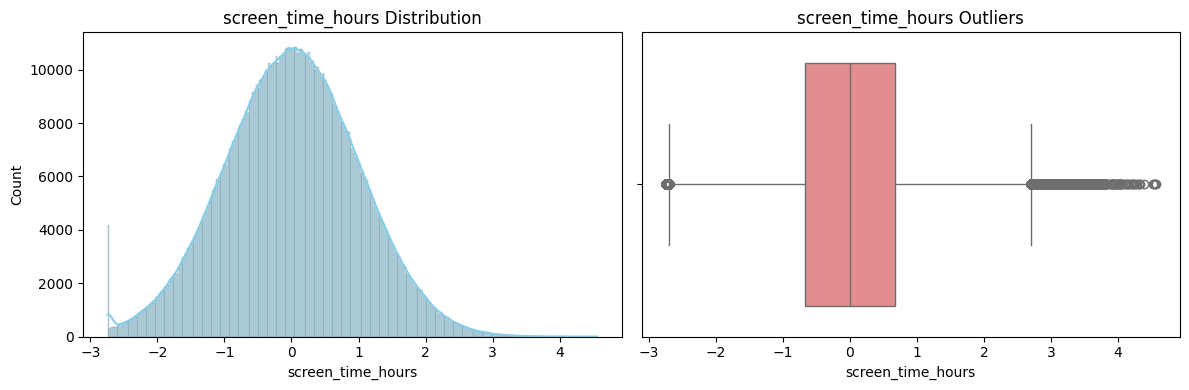

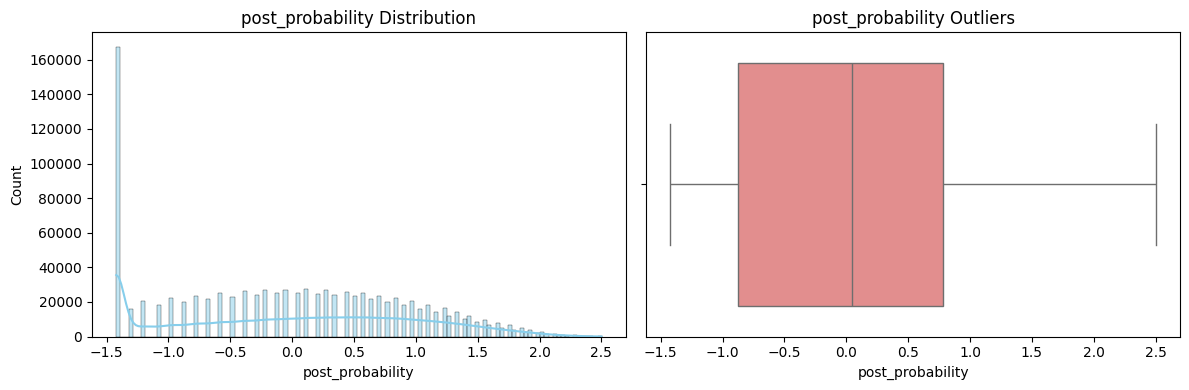

In [25]:
# Plot Histograms and Boxplots side-by-side for each numerical column
for col in skew_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Histogram with KDE curve
    sns.histplot(data=df, x=col, kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title(f'{col} Distribution')
    
    # Boxplot for outliers
    sns.boxplot(data=df, x=col, ax=axes[1], color='lightcoral')
    axes[1].set_title(f'{col} Outliers')
    
    plt.tight_layout()
    plt.show()

In [26]:
z_scores = np.abs(stats.zscore(df[num_cols], nan_policy='omit'))
outliers = (z_scores > 3).sum()
print(outliers)

1189


After applying transformation outliers reduced from 2403 to 1189

## 4.2 One-Hot Encoding

In [27]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

df = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

Splitting Data before Feature scaling


In [28]:
X = df.drop('active_poster', axis=1)
y = df['active_poster']

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

## 4.3 Standard Scaling

In [30]:
# Implement StandardScaler to eliminate scaling bias across numerical features.

all_numeric_cols  = X_train.select_dtypes(include='number').columns # keep only non-binary numeric columns and scale them

cols_to_scale  = [c for c in all_numeric_cols  if df[c].nunique() > 2]

scaler = StandardScaler()

X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])

# Transform ONLY if using fit_transform so X_test uses it's own mean value
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

In [31]:
X_train = pd.DataFrame(X_train)
X_train.head(2)

,age,screen_time_hours,platform_count,social_anxiety,self_esteem,privacy_score,trend_fatigue_score,burnout_score,social_comparison,attention_span_score,post_probability,decline_reason_Fear of Judgment,decline_reason_Low Interest,decline_reason_Privacy Concern
566853,-0.122459,-0.040471,-0.000626,0.000702,1.581720,1.580446,-1.582014,-0.317457,0.315406,-0.062363,0.205971,False,False,True
382311,-0.370541,-0.952686,1.413463,-1.264116,-0.632017,-0.950088,-0.000566,-1.582329,-0.633171,-1.134286,1.602241,False,True,False


In [32]:
df.shape

(1000000, 15)

# 5. Machine Learning and Hyperparameter Tuning

In [33]:
from sklearn.model_selection import RandomizedSearchCV, KFold, cross_val_score

# Linear Models (Classification)
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import RidgeClassifier
from sklearn.linear_model import SGDClassifier

# Tree-Based Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Boosting Models
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Metrics (Classification)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

In [34]:
models = {

    # ============================
    # Linear Models (Baseline)
    # ============================
    "Logistic Regression": LogisticRegression(
        n_jobs=-1
    ),

    "Ridge Regression": RidgeClassifier(),

    "Lasso Regression": SGDClassifier(penalty='l1'),

    "ElasticNet Regression": SGDClassifier(penalty='elasticnet'),

    # ============================
    # Tree-Based Models
    # ============================
    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),

    # ============================
    # Boosting Models
    # ============================
    "XGBoost": XGBClassifier(
        random_state=42,
        objective='binary:logistic',
        tree_method='hist'
    ),

    "LightGBM": LGBMClassifier(
        random_state=42,
        force_col_wise=True,
        verbose=-1
    )
}

In [35]:
param_grids = {

    # ============================
    # Linear Models
    # ============================
    "Logistic Regression": {},

    "Ridge Regression": {
        "alpha": [0.01, 0.1, 1, 10, 100],
        "max_iter": [1000, 2000, 5000]
    },

    "Lasso Regression": {
        "alpha": [0.001, 0.01, 0.1, 1, 10],
        "max_iter": [1000, 2000, 5000]
    },

    "ElasticNet Regression": {
        "alpha": [0.001, 0.01, 0.1, 1],
        "l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9],
        "max_iter": [1000, 2000, 5000]
    },

    # ============================
    # Tree-Based Models
    # ============================
    "Decision Tree": {
        "max_depth": [3, 5, 7, 10, 15, None],
        "min_samples_split": [2, 5, 10, 20],
        "min_samples_leaf": [1, 2, 5, 10],
        "criterion": ["gini", "entropy", "log_loss"]
    },

    "Random Forest": {
        "n_estimators": [100, 200, 300, 500],
        "max_depth": [3, 5, 7, 10, None],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "max_features": ["sqrt", "log2"]
    },

    # ============================
    # Boosting Models 
    # ============================
    "XGBoost": {
        "n_estimators": [100, 200, 300, 500],
        "max_depth": [3, 4, 5, 6, 7],
        "learning_rate": [0.01, 0.05, 0.1, 0.2],
        "subsample": [0.6, 0.7, 0.8, 1.0],
        "colsample_bytree": [0.6, 0.7, 0.8, 1.0],
        "gamma": [0, 0.1, 0.2]
    },

    "LightGBM": {
        "n_estimators": [100, 200, 300, 500],
        "learning_rate": [0.01, 0.03, 0.05, 0.1],
        "num_leaves": [15, 31, 50, 70],
        "max_depth": [-1, 3, 5, 7, 10],
        "min_child_samples": [5, 10, 20, 30],
        "subsample": [0.7, 0.8, 1.0],
        "colsample_bytree": [0.7, 0.8, 1.0]
    }
}

In [36]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

In [37]:
best_model = None
best_score = -float("inf")
best_model_name = ""

results = {}

for name, model in models.items():
    
    print(f"\nRunning RandomizedSearchCV for {name}...")
    
    random_search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_grids[name],
        cv=kf,
        scoring='accuracy',
        n_jobs=1,
        n_iter=20 if name == "LightGBM" else 50,
        random_state=42
    )

    random_search.fit(X_train, y_train)

    results[name] = {
        "Best Params": random_search.best_params_,
        "Best CV Score (Accuracy)": random_search.best_score_
    }

    print(name)
    print("Best Params:", random_search.best_params_)
    print("Best CV Score (Accuracy):", random_search.best_score_)

    # STORE ONLY BEST MODEL
    if random_search.best_score_ > best_score:
        best_score = random_search.best_score_
        best_model = random_search.best_estimator_
        best_model_name = name


Running RandomizedSearchCV for Logistic Regression...


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 1 is smaller than n_iter=50. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Logistic Regression
Best Params: {}
Best CV Score (Accuracy): 0.8381299999999999

Running RandomizedSearchCV for Ridge Regression...


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 15 is smaller than n_iter=50. Running 15 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Ridge Regression
Best Params: {'max_iter': 1000, 'alpha': 0.01}
Best CV Score (Accuracy): 0.83836

Running RandomizedSearchCV for Lasso Regression...


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 15 is smaller than n_iter=50. Running 15 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Lasso Regression
Best Params: {'max_iter': 1000, 'alpha': 0.001}
Best CV Score (Accuracy): 0.83836

Running RandomizedSearchCV for ElasticNet Regression...
ElasticNet Regression
Best Params: {'max_iter': 1000, 'l1_ratio': 0.1, 'alpha': 0.001}
Best CV Score (Accuracy): 0.83836

Running RandomizedSearchCV for Decision Tree...
Decision Tree
Best Params: {'min_samples_split': 10, 'min_samples_leaf': 10, 'max_depth': 5, 'criterion': 'log_loss'}
Best CV Score (Accuracy): 0.8385987500000001

Running RandomizedSearchCV for Random Forest...
Random Forest
Best Params: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 10}
Best CV Score (Accuracy): 0.8384937499999999

Running RandomizedSearchCV for XGBoost...
XGBoost
Best Params: {'subsample': 0.6, 'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.01, 'gamma': 0.1, 'colsample_bytree': 0.8}
Best CV Score (Accuracy): 0.83856

Running RandomizedSearchCV for LightGBM...
LightGBM
Best Params

In [38]:
df_comparison = pd.DataFrame(
    [(model, info["Best CV Score (Accuracy)"]) for model, info in results.items()],
    columns=['Model', 'Accuracy']
)

df_comparison = df_comparison.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

print("🏆 Model Comparison Leaderboard 🏆")
print(df_comparison)

🏆 Model Comparison Leaderboard 🏆
                   Model  Accuracy
0               LightGBM  0.838611
1          Decision Tree  0.838599
2                XGBoost  0.838560
3          Random Forest  0.838494
4       Lasso Regression  0.838360
5  ElasticNet Regression  0.838360
6       Ridge Regression  0.838360
7    Logistic Regression  0.838130


In [39]:
print(type(best_model))
print(best_model_name)

from sklearn.utils.validation import check_is_fitted

check_is_fitted(best_model)

<class 'lightgbm.sklearn.LGBMClassifier'>
LightGBM


In [40]:
y_pred = best_model.predict(X_test)

In [41]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
cm = confusion_matrix(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("Confusion Matrix:\n", cm)

Accuracy: 0.8371
Precision: 0.7839915519808758
Recall: 0.8371
F1 Score: 0.7664830568595892
Confusion Matrix:
 [[167031    382]
 [ 32198    389]]


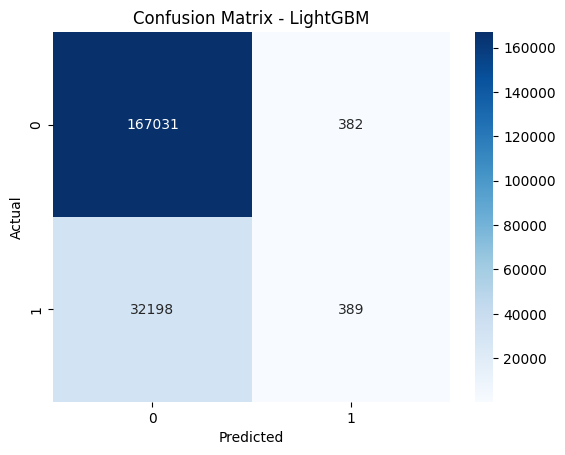

In [42]:
cm = confusion_matrix(y_test, y_pred)

labels = np.unique(y_test)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)

plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

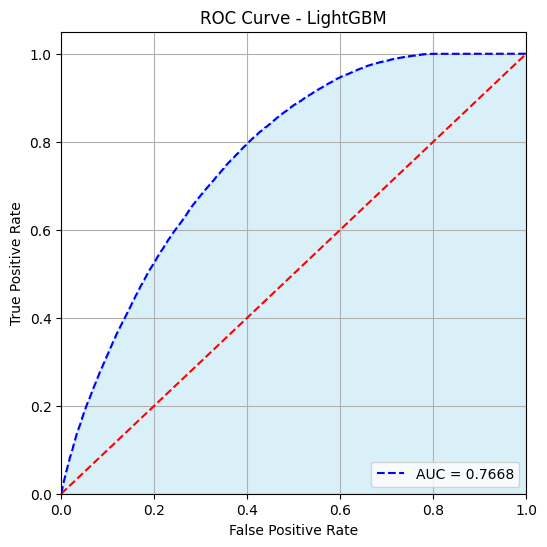

In [43]:
from sklearn.metrics import roc_curve, roc_auc_score

# Predict probabilities
y_proba = best_model.predict_proba(X_test)[:, 1]

# Calculate ROC-AUC
auc = roc_auc_score(y_test, y_proba)

# Calculate ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

# Plot ROC Curve
plt.figure(figsize=(6, 6), dpi=100)
plt.plot(fpr, tpr, linestyle='--', color='blue', label=f'AUC = {auc:.4f}')
plt.fill_between(fpr, tpr, alpha=0.3, color='skyblue')

# Diagonal reference line
plt.plot([0, 1], [0, 1], 'r--')

plt.xlim([0, 1])
plt.ylim([0, 1.05])

plt.title(f"ROC Curve - {best_model_name}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")

plt.grid(True)
plt.show()

Hope you like my work :)